In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [ ]:
categories = ['Venomous', 'Non Venomous']
IMG_SIZE = 64

def load_data_from_drive(directory):
    data, labels = [], []
    for category in categories:
        path = os.path.join(directory, category)
        if not os.path.exists(path):
            print(f"Thư mục {path} chưa được upload")
            continue
        class_num = categories.index(category)
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    data.append(img.flatten())
                    labels.append(class_num)
            except: continue
    return np.array(data), np.array(labels)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = '/content/drive/MyDrive/train'
test_dir = '/content/drive/MyDrive/test'
X_train, y_train = load_data_from_drive(train_dir)
X_test, y_test = load_data_from_drive(test_dir)

#Giảm chiều dữ liệu bằng PCA (Giảm từ 12,288 chiều xuống 100 chiều)

In [ ]:
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model = SVC(kernel='rbf', C=1000, probability=True, class_weight='balanced')

model.fit(X_train_pca, y_train)

SVC(C=1000, class_weight='balanced', probability=True)

#SVM

In [ ]:
model = SVC(kernel='rbf', C=1000, probability=True)
model.fit(X_train_pca, y_train)

SVC(C=1000, probability=True)

#Đánh giá kết quả

In [ ]:
y_pred = model.predict(X_test_pca)
print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(y_test, y_pred, target_names=categories))


BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

    Venomous       0.63      0.74      0.68       141
Non Venomous       0.64      0.52      0.57       128

    accuracy                           0.63       269
   macro avg       0.63      0.63      0.62       269
weighted avg       0.63      0.63      0.63       269



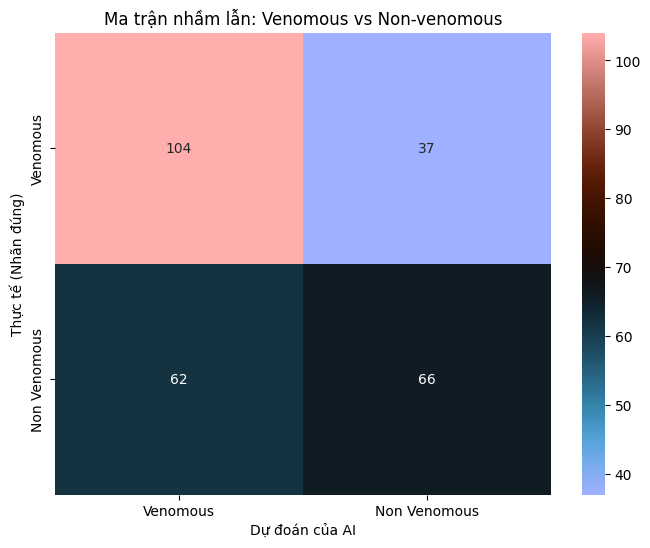

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='berlin',
            xticklabels=categories, yticklabels=categories)
plt.xlabel('Dự đoán của AI')
plt.ylabel('Thực tế (Nhãn đúng)')
plt.title('Ma trận nhầm lẫn: Venomous vs Non-venomous')
plt.show()

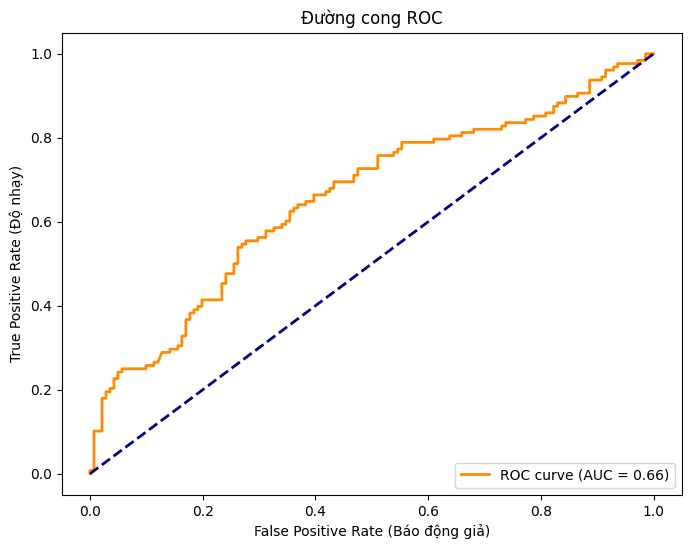

In [ ]:
from sklearn.metrics import roc_curve, auc
y_probs = model.predict_proba(X_test_pca)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Báo động giả)')
plt.ylabel('True Positive Rate (Độ nhạy)')
plt.title('Đường cong ROC')
plt.legend(loc="lower right")
plt.show()

=> ĐANG KIỂM TRA 10 MẪU NGẪU NHIÊN...


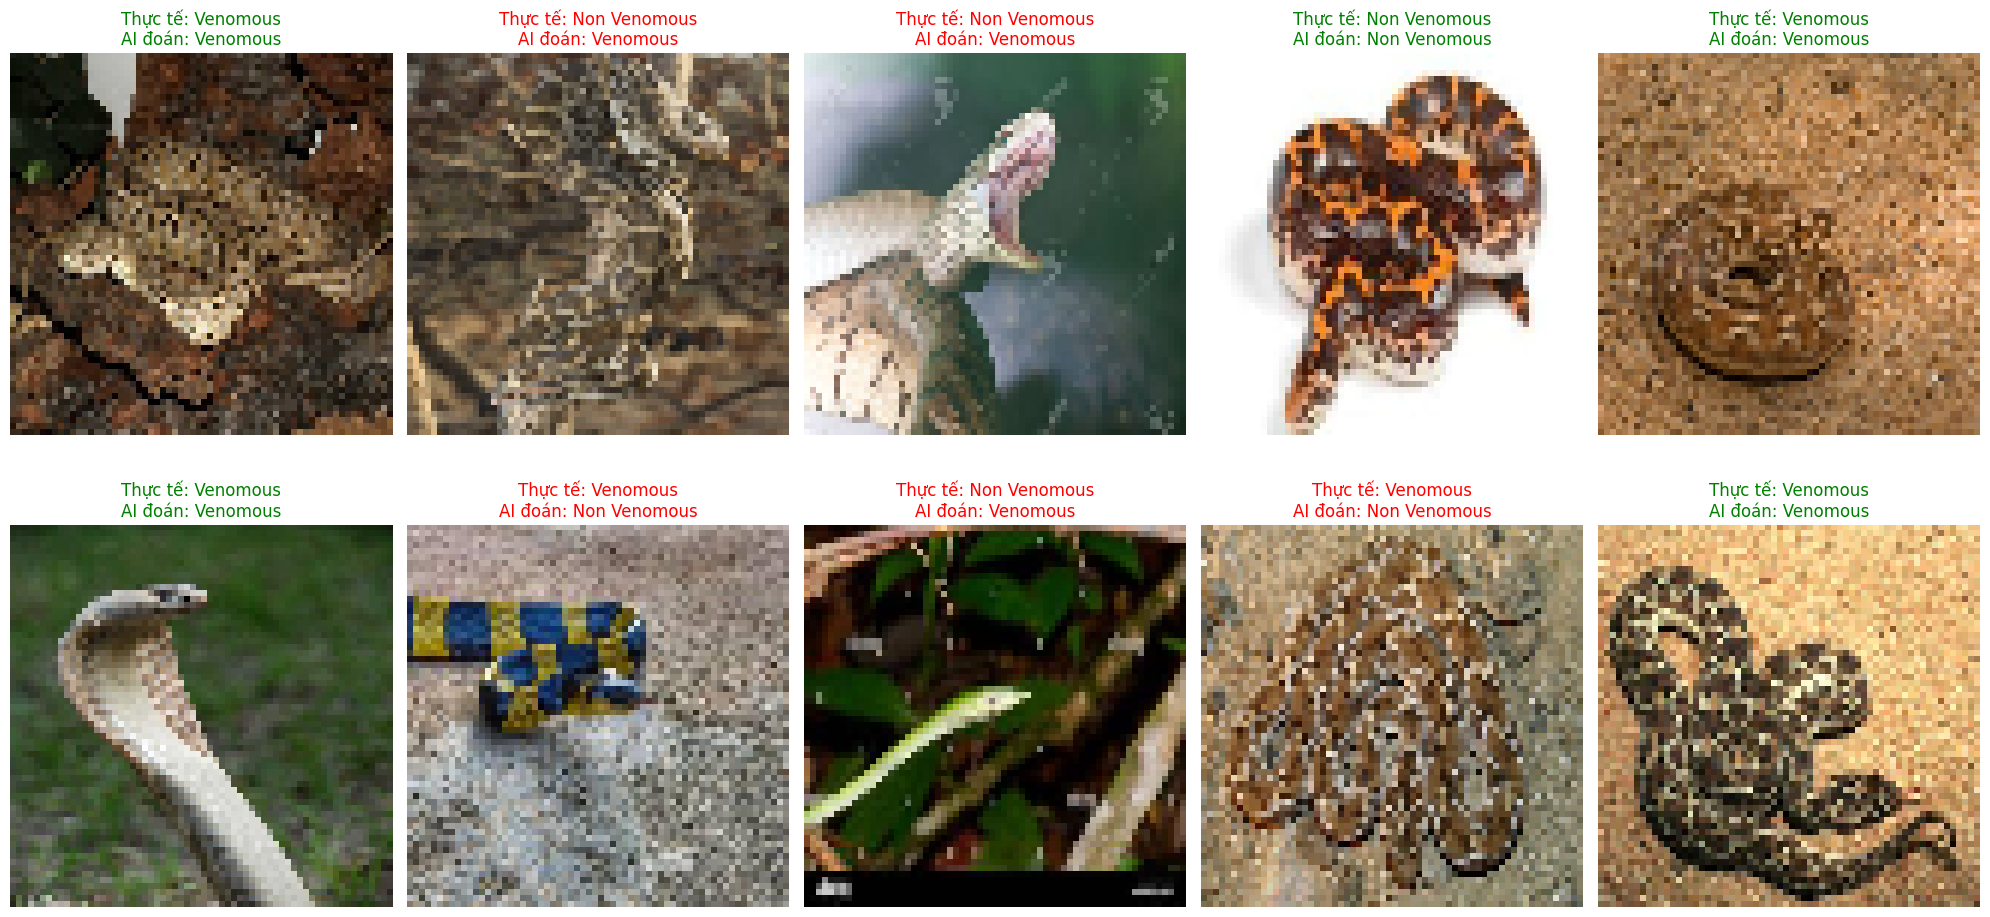

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Chọn 10 chỉ số ngẫu nhiên từ tập Test
random_indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(20, 10))
print("=> ĐANG KIỂM TRA 10 MẪU NGẪU NHIÊN...")

for i, idx in enumerate(random_indices):
    img_flat = X_test[idx]
    img_show = img_flat.reshape(64, 64, 3).astype('uint8')
    img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    true_label = categories[y_test[idx]]
    pred_label = categories[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'    # Xanh nếu đúng, Đỏ nếu sai
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_show)
    plt.title(f"Thực tế: {true_label}\nAI đoán: {pred_label}", color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

#Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# KHỞI TẠO FOREST

In [ ]:
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)

# HUẤN LUYỆN

In [ ]:
rf_model.fit(X_train_pca, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

#Dự đoán

In [ ]:
y_pred_rf = rf_model.predict(X_test_pca)

# BẢNG ĐIỂM

In [ ]:
print(classification_report(y_test, y_pred_rf, target_names=categories))

              precision    recall  f1-score   support

    Venomous       0.56      0.99      0.71       141
Non Venomous       0.90      0.15      0.26       128

    accuracy                           0.59       269
   macro avg       0.73      0.57      0.48       269
weighted avg       0.72      0.59      0.50       269



# MA TRẬN NHẦM LẪN CHO RANDOM FOREST

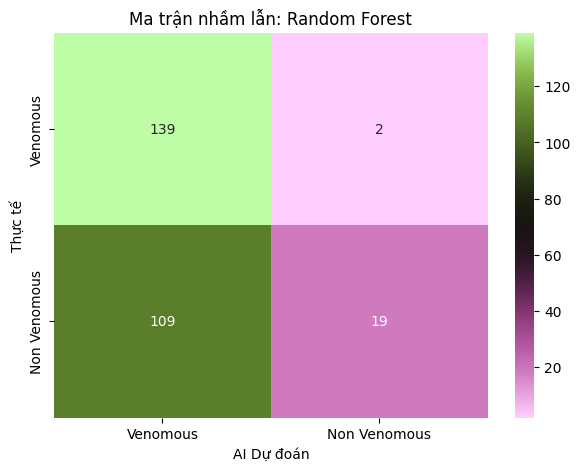

In [ ]:
# 5. VẼ MA TRẬN NHẦM LẪN CHO RANDOM FOREST
plt.figure(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='vanimo',
            xticklabels=categories, yticklabels=categories)
plt.title('Ma trận nhầm lẫn: Random Forest')
plt.xlabel('AI Dự đoán')
plt.ylabel('Thực tế')
plt.show()

#Thử nghiệm

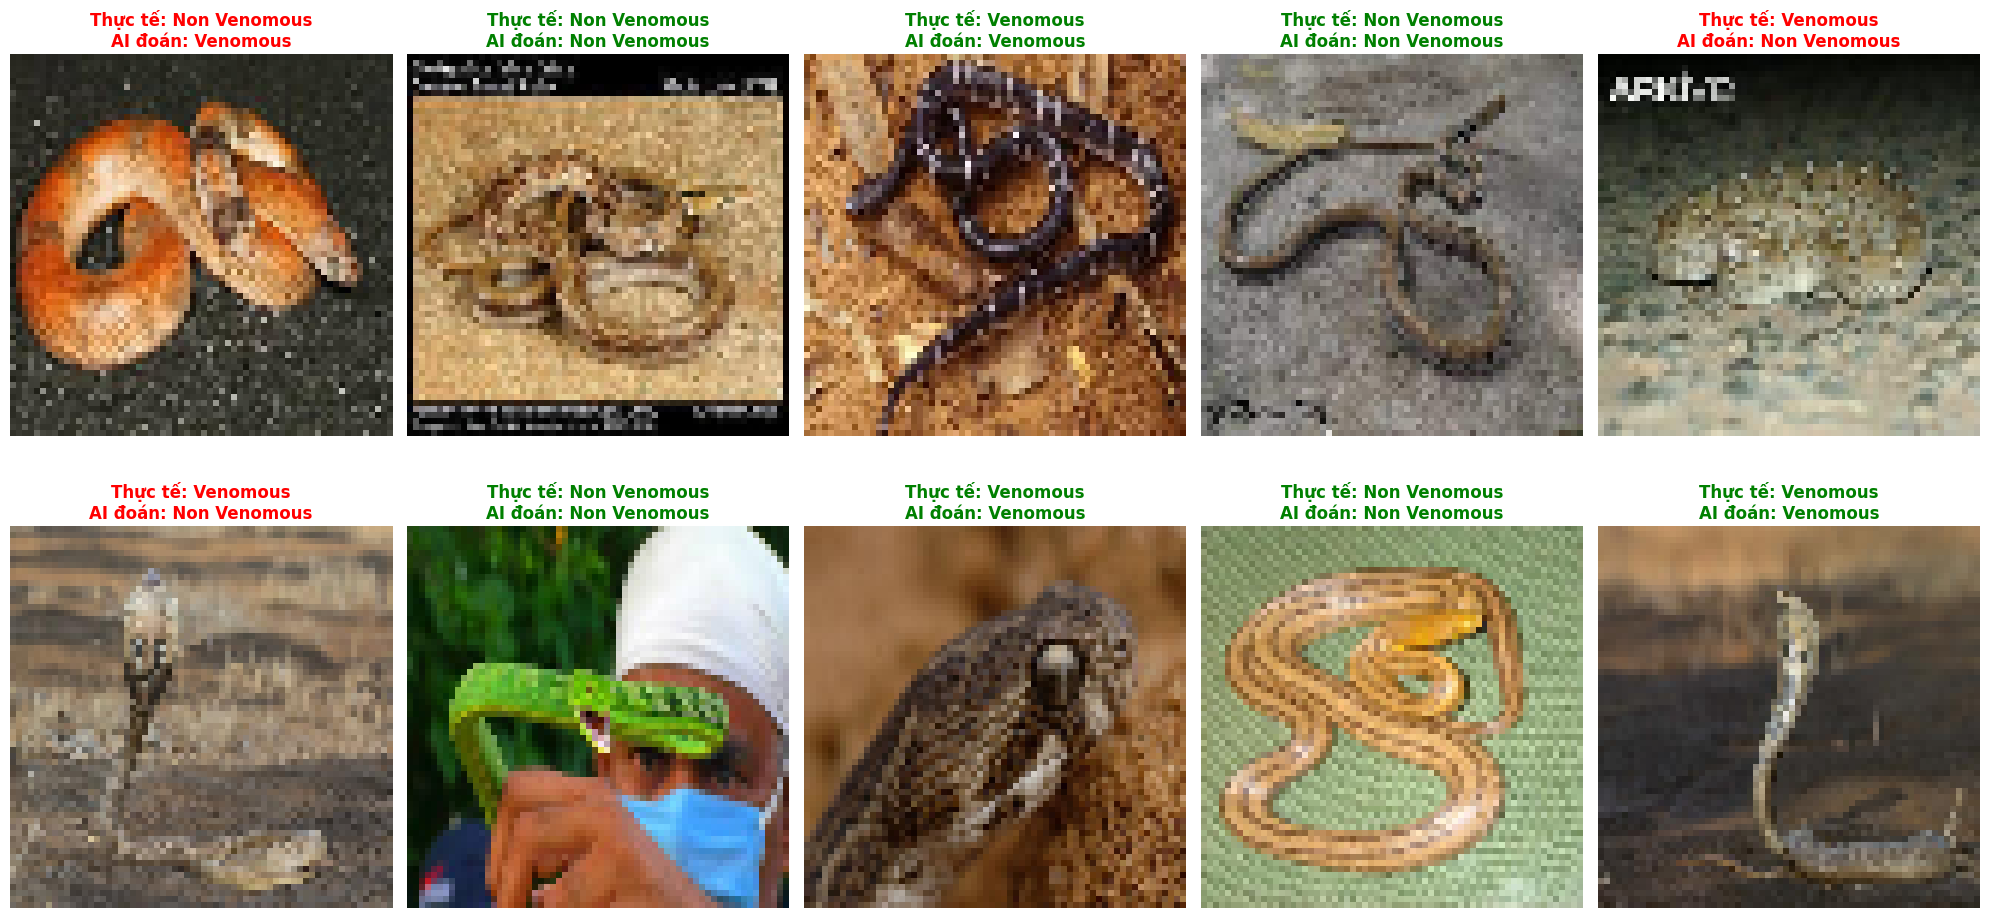

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
random_indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(20, 10))

for i, idx in enumerate(random_indices):
    img_flat = X_test[idx]

    img_show = img_flat.reshape(64, 64, 3).astype('uint8')
    img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    true_label = categories[y_test[idx]]
    pred_label = categories[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_show)
    plt.title(f"Thực tế: {true_label}\nAI đoán: {pred_label}", color=color, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

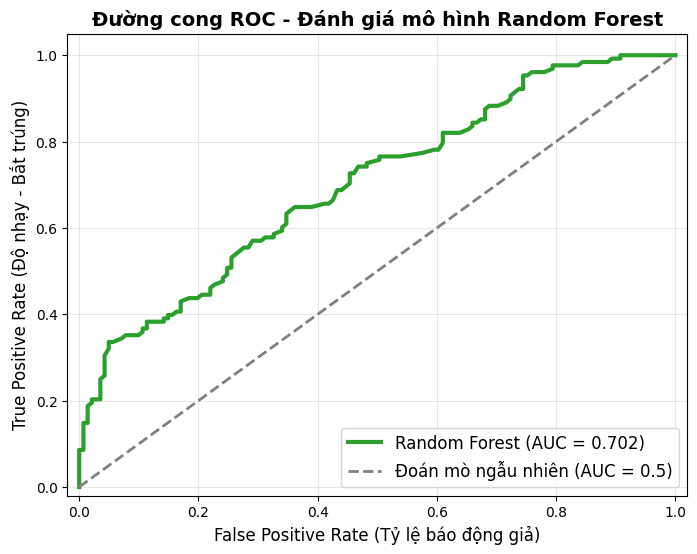


=> ĐIỂM SỐ AUC CỦA RỪNG NGẪU NHIÊN LÀ: 0.702


In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. Lấy xác suất dự đoán thay vì nhãn cứng (Quan trọng!)
# predict_proba trả về xác suất cho cả 2 lớp [Xác suất lớp 0, Xác suất lớp 1]
# Ta lấy [:, 1] tức là lấy cột xác suất của lớp thứ 1 để vẽ biểu đồ
y_probs_rf = rf_model.predict_proba(X_test_pca)[:, 1]

# 2. Tính toán các tỷ lệ: FPR (Báo động giả) và TPR (Độ nhạy)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)

# 3. Tính điểm AUC (Area Under the Curve)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 4. TRỰC QUAN HÓA BẰNG MATPLOTLIB
plt.figure(figsize=(8, 6))

# Vẽ đường cong của Random Forest (màu xanh lá cho hợp với "Rừng")
plt.plot(fpr_rf, tpr_rf, color='#2ca02c', lw=3, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# Vẽ đường chéo 50/50 (Đường ranh giới của việc đoán mò)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Đoán mò ngẫu nhiên (AUC = 0.5)')

# Trang trí biểu đồ cho chuyên nghiệp
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo động giả)', fontsize=12)
plt.ylabel('True Positive Rate (Độ nhạy - Bắt trúng)', fontsize=12)
plt.title('Đường cong ROC - Đánh giá mô hình Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"\n=> ĐIỂM SỐ AUC CỦA RỪNG NGẪU NHIÊN LÀ: {roc_auc_rf:.3f}")

#PHÂN LOẠI BẰNG LOGISTIC


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Khởi tạo mô hình

In [ ]:
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

# HUẤN LUYỆN

In [ ]:
lr_model.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# DỰ ĐOÁN

In [ ]:
y_pred_lr = lr_model.predict(X_test_pca)

# BẢNG ĐIỂM

In [ ]:
print(classification_report(y_test, y_pred_lr, target_names=categories))

              precision    recall  f1-score   support

    Venomous       0.56      0.86      0.68       141
Non Venomous       0.62      0.26      0.36       128

    accuracy                           0.57       269
   macro avg       0.59      0.56      0.52       269
weighted avg       0.59      0.57      0.53       269



#Ma trận nhầm lẫn

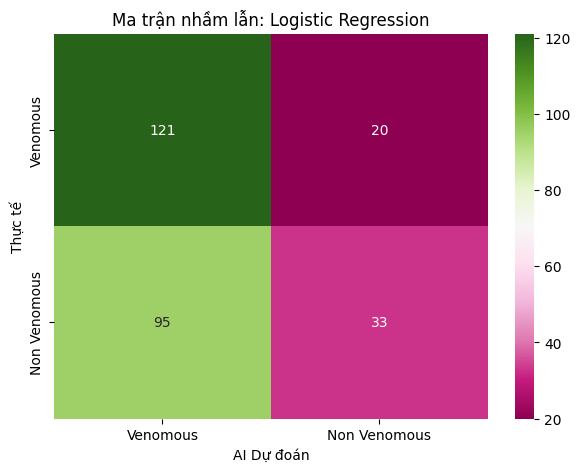

In [ ]:
plt.figure(figsize=(7, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='PiYG',
            xticklabels=categories, yticklabels=categories)
plt.title('Ma trận nhầm lẫn: Logistic Regression')
plt.xlabel('AI Dự đoán')
plt.ylabel('Thực tế')
plt.show()

#Thử 10 ảnh

=> ĐANG KIỂM TRA 10 MẪU VỚI LOGISTIC REGRESSION (MÁY DỰ BÁO)...


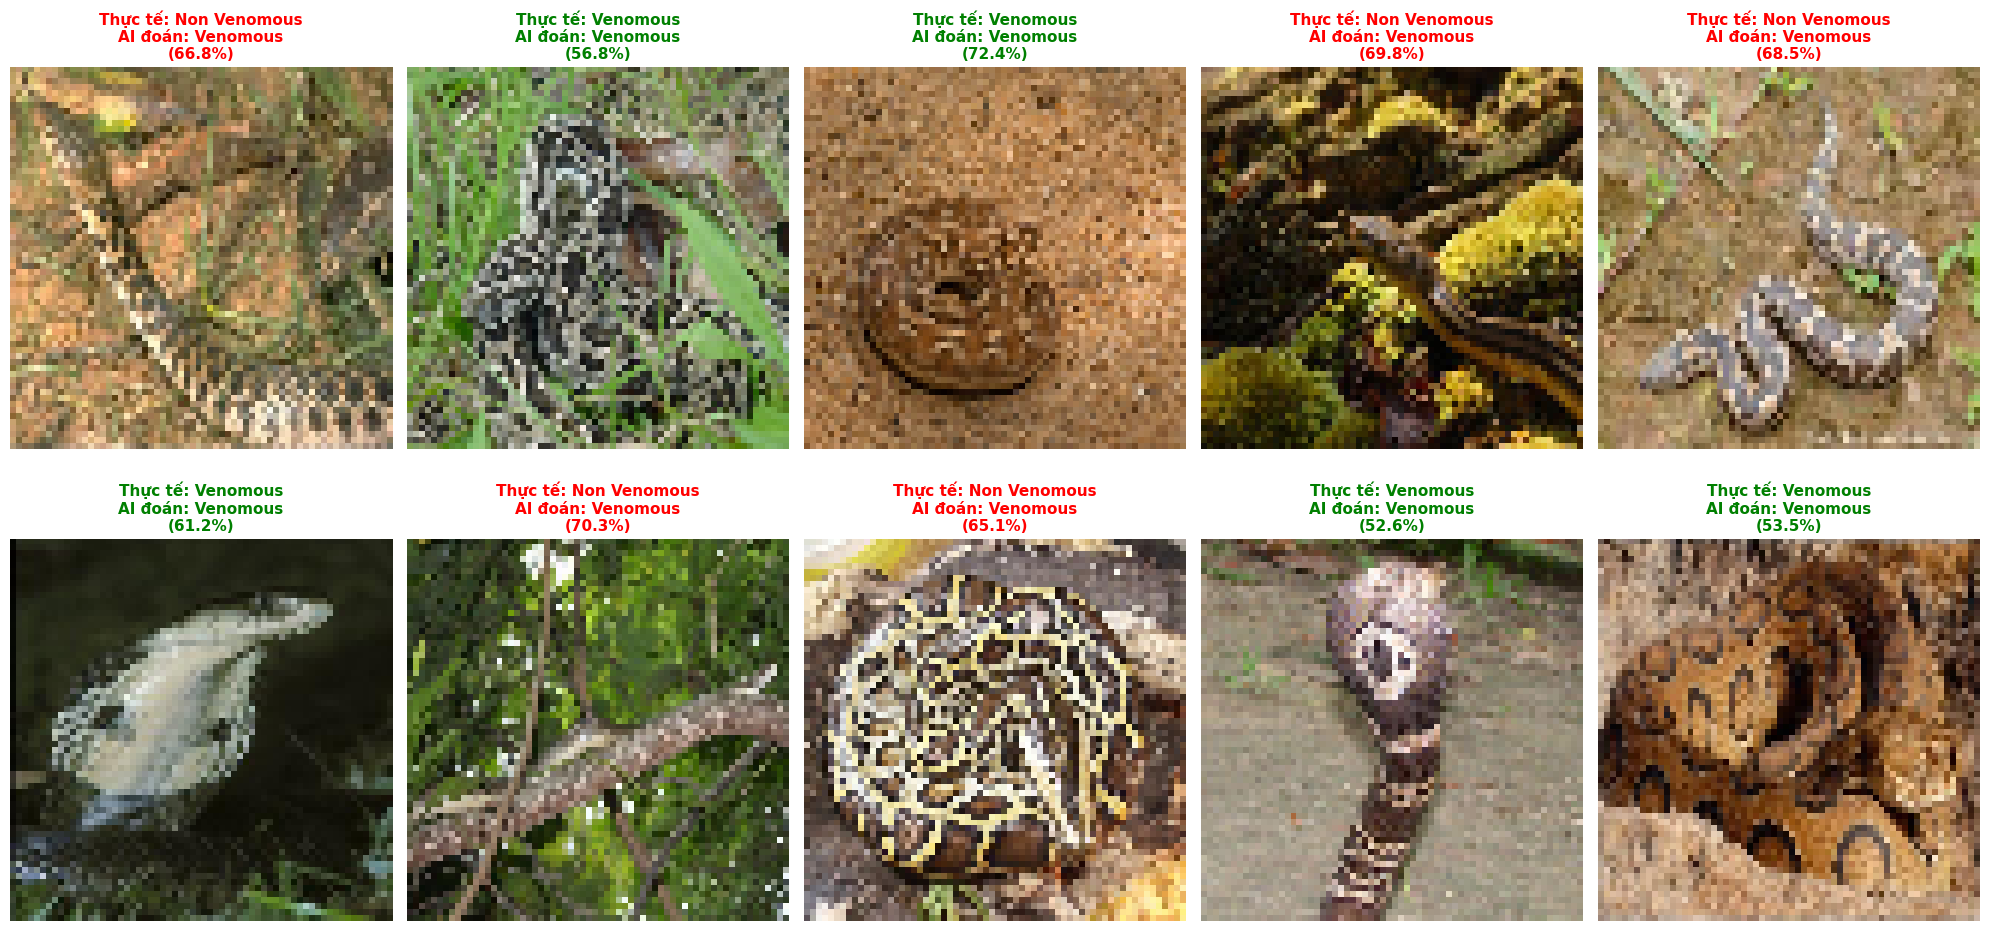

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# 1. Chọn 10 chỉ số ngẫu nhiên từ tập Test
random_indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(20, 10))
print("=> ĐANG KIỂM TRA 10 MẪU VỚI LOGISTIC REGRESSION (MÁY DỰ BÁO)...")

# Dự đoán nhãn cho tập test (nếu chưa làm)
y_pred_lr = lr_model.predict(X_test_pca)

for i, idx in enumerate(random_indices):
    # Lấy ảnh gốc và đưa về 64x64
    img_flat = X_test[idx]
    img_show = img_flat.reshape(64, 64, 3).astype('uint8')
    img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

    # Lấy nhãn thật và nhãn dự đoán
    true_label = categories[y_test[idx]]
    pred_label = categories[y_pred_lr[idx]]

    # Lấy xác suất (Confidence) từ hàm Sigmoid
    # predict_proba trả về [P(lớp 0), P(lớp 1)]
    probs = lr_model.predict_proba(X_test_pca[idx].reshape(1, -1))[0]
    confidence = np.max(probs) * 100

    # Màu sắc: Xanh = Đúng, Đỏ = Sai
    color = 'green' if true_label == pred_label else 'red'

    plt.subplot(2, 5, i + 1)
    plt.imshow(img_show)
    plt.title(f"Thực tế: {true_label}\nAI đoán: {pred_label}\n({confidence:.1f}%)",
              color=color, fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

#Vẽ ROC&AUC

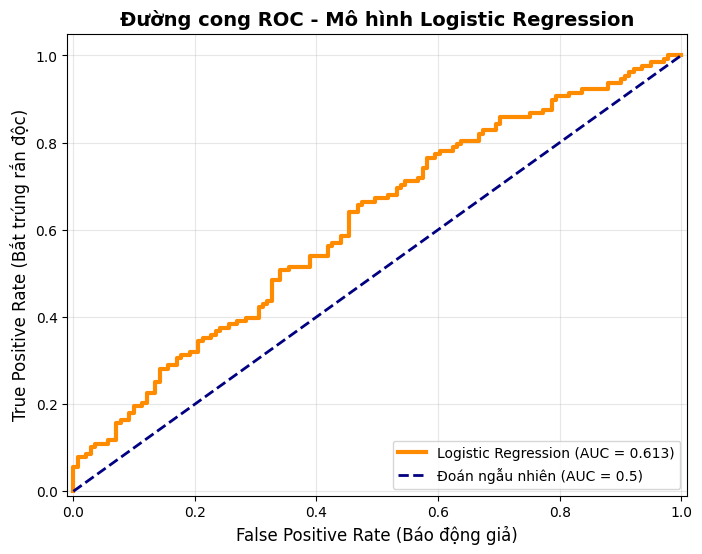


=> ĐIỂM SỐ AUC CỦA LOGISTIC REGRESSION: 0.613


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Lấy xác suất dự đoán cho lớp Venomous (lớp 1)
# predict_proba trả về [xác suất Non-venomous, xác suất Venomous]
y_probs_lr = lr_model.predict_proba(X_test_pca)[:, 1]

# 2. Tính FPR (Tỷ lệ báo động giả) và TPR (Độ nhạy)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_probs_lr)

# 3. Tính điểm AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

# 4. TRỰC QUAN HÓA
plt.figure(figsize=(8, 6))

# Vẽ đường cong Logistic Regression (màu cam đặc trưng)
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=3,
         label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Vẽ đường chéo nét đứt (ngưỡng đoán mò 50/50)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Đoán ngẫu nhiên (AUC = 0.5)')

# Trang trí biểu đồ
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate (Báo động giả)', fontsize=12)
plt.ylabel('True Positive Rate (Bắt trúng rắn độc)', fontsize=12)
plt.title('Đường cong ROC - Mô hình Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\n=> ĐIỂM SỐ AUC CỦA LOGISTIC REGRESSION: {roc_auc_lr:.3f}")

#